# Analysis of Dataset
Dataset: Fake and real news articles

Goal: Binary classification of news articles.

Features:
- title
- text

Target:
- label (0 = real, 1 = fake)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_csv("../data/Dataset.csv")

## Dataset Overview

In [3]:
# Examining Dataset 
print("Dataset shape:",df.shape)
print("\nSample: ")
df.head(1)

Dataset shape: (72134, 4)

Sample: 


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


## Missing values

In [5]:
df.isna().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [6]:
(df.isna().mean()*100).round(2)

Unnamed: 0    0.00
title         0.77
text          0.05
label         0.00
dtype: float64

## Class Distribution

In [7]:
df["label"].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [8]:
df["label"].value_counts(normalize=True) * 100

label
1    51.440375
0    48.559625
Name: proportion, dtype: float64

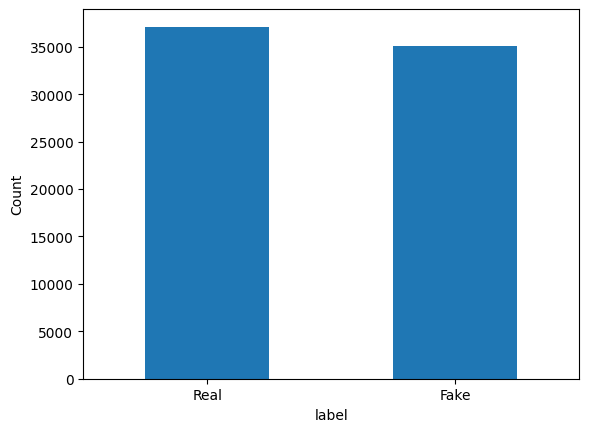

In [9]:
df["label"].value_counts().plot(kind="bar")
plt.xticks([0, 1], ["Real", "Fake"], rotation=0)
plt.ylabel("Count")
plt.show()

## Text Length Analysis

In [10]:
df["title_length"] = df["title"].fillna("").str.split().str.len()
df["text_length"] = df["text"].fillna("").str.split().str.len()

df.groupby("label")[["title_length", "text_length"]].mean()

,title_length,text_length
label,,
0,11.046620,577.615536
1,13.236916,505.562012


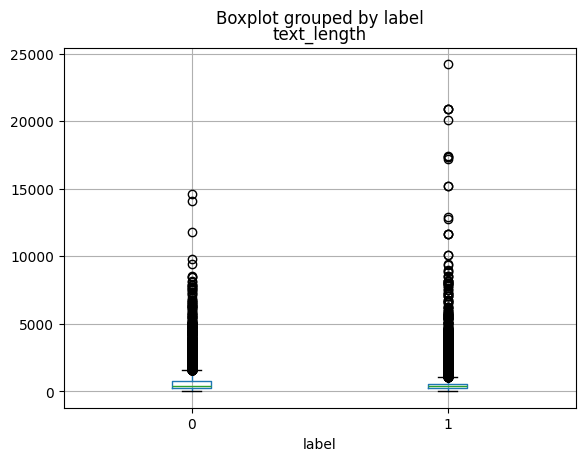

In [11]:
df.boxplot(column="text_length", by="label")
plt.show()

## Most Common words

In [12]:
# Converting datatypes
df['title'] = df['title'].astype('string')
df['text'] = df['text'].astype('string')

# Treating missing values
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')

words = " ".join(df["text"]).split()

Counter(words).most_common(20)

[('the', 1981516),
 ('to', 1087627),
 ('of', 982372),
 ('and', 866653),
 ('a', 837706),
 ('in', 691115),
 ('that', 482397),
 ('is', 363392),
 ('for', 346248),
 ('on', 340912),
 ('with', 241083),
 ('was', 241059),
 ('as', 215002),
 ('The', 211291),
 ('he', 203661),
 ('by', 189267),
 ('it', 180007),
 ('his', 178535),
 ('have', 176486),
 ('be', 174911)]

In [13]:
source_terms = [
    "reuters",
    "breitbart",
    "cnn",
    "bbc",
    "fox news"
]

for term in source_terms:
    count = df["text"].str.contains(
        term,
        case=False,
        na=False
    ).sum()

    print(f"{term}: {count}")

reuters: 22299
breitbart: 3242
cnn: 4701
bbc: 700
fox news: 3900


# Key Findings
* The dataset contains approximately 72,000 news articles with three primary fields: title, text, and label.
* Both title and text columns are stored as object types and require conversion to string format during preprocessing.
* Missing values are limited:
    -   title: 558 missing entries (~0.77%)
    -   text: 39 missing entries (~0.05%)
* Missing text fields are rare, indicating that nearly all predictions can rely on article content.
* The dataset is well balanced, with an approximate class distribution of 51.5% real news and 48.5% fake news.
* Average text lengths are similar across classes:
    -   Average title length: approximately 11–13 words
    -   Average article length: approximately 505–577 words
* Similar document lengths suggest that article size alone is unlikely to be a strong predictor of authenticity.
* Publisher identifiers appear frequently within the corpus. For example, the term reuters occurs more than 22,000 times.
* The high frequency of source identifiers suggests the possibility of dataset leakage, motivating later experiments that remove publisher names during preprocessing.
* Preliminary inspection of raw word frequencies was not informative because results were dominated by stopwords, capitalization differences, and punctuation artifacts. Meaningful vocabulary analysis requires preprocessing before token frequency analysis.

## Impact on Modeling Decisions

Based on the exploratory analysis:

- Missing values are replaced with empty strings.
- Text fields are converted to string datatype.
- Lowercasing and punctuation removal are applied.
- Stopwords are removed during preprocessing.
- Title and article text are modeled separately.
- Source identifier removal is evaluated as an ablation experiment.
- Accuracy, precision, recall, and F1 score are appropriate metrics because the dataset is approximately balanced.